<a href="https://colab.research.google.com/github/blancavazquez/Programa-intensivo-2026-Modulo3/blob/main/notebooks/sesion_miercoles/1_Perceptron_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programa Intensivo en Ciencia de Datos de los Fundamentos al Deep Learning**

## **Módulo 3**: *Redes Neuronales Artificiales*

## **Objetivo**: Construir y entrenar un Perceptrón Multicapa (MLP). Visualizar sus resultados y rendimiento. Esta libreta está inspirada del material desarrollado por el Ing. Gabriel Carcedo, estudiante del PCIC, IIMAS.


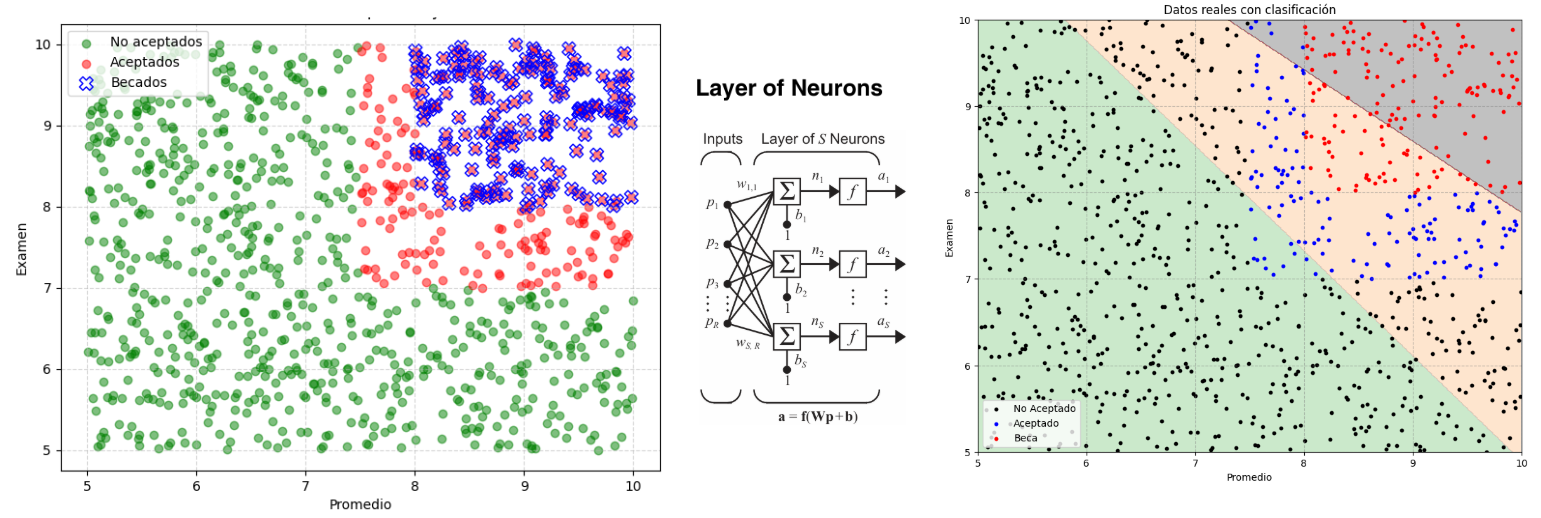

---

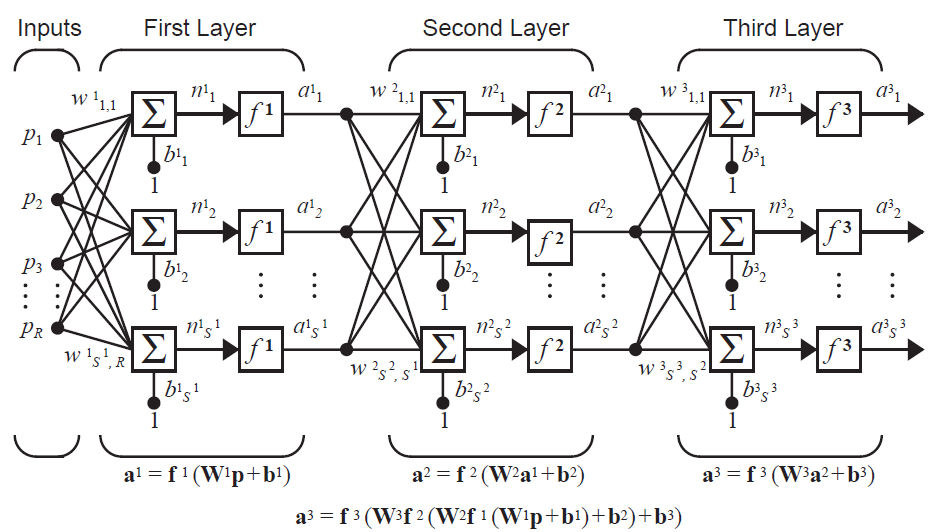

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Paquetes y Librerías 📚

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import pandas as pd

# Funciones de activación 📈

In [ ]:
def step(n):
    return np.where(n >= 0, 1, 0)

def sigmoid(n):
    return 1 / (1 + np.exp(-n))

def tanh(n):
    return np.tanh(n)

def relu(n):
    return np.maximum(0, n)


---
# **Perceptrón Multicapa (MLP)**
---

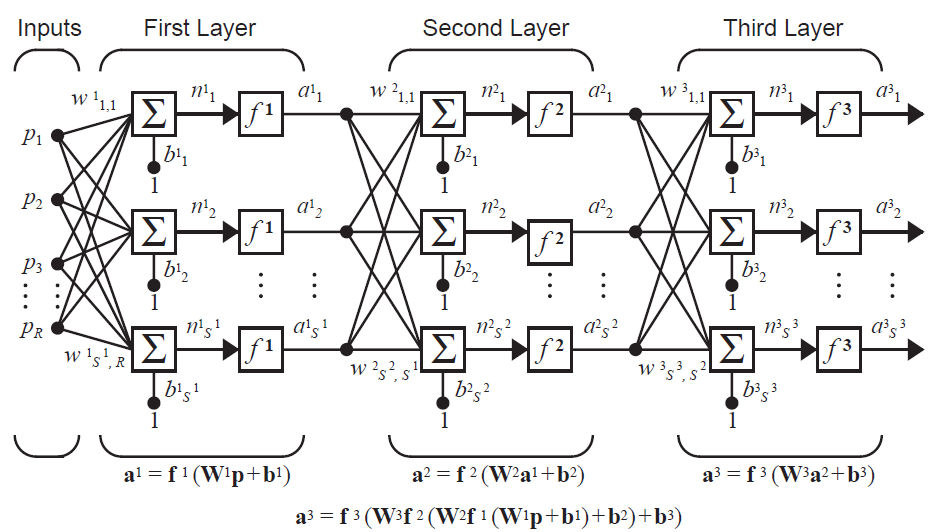

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Generar conjunto de datos

In [ ]:
# Número de registros
samples = 2000

np.random.seed(10)  # semilla para reproducibilidad

# Generar promedios aleatorios
promedios = np.random.uniform(5, 10, samples)   # promedios de 5 a 10
calif_examen  = np.random.uniform(5, 10, samples)     # resultados de examen de 50 a 100
extracurriculares = np.random.randint(0, 11, samples)  # actividades extracurriculares de 0 a 10

# Etiquetas
aceptado = ((promedios > 6.5) & (calif_examen > 6)).astype(int)   # regla: si promedio > 7.5 y examen > 70 → aceptado=1
beca = ((promedios > 7) & (calif_examen > 7) & (extracurriculares > 4)).astype(int)  # regla: si promedio > 8 y examen > 80 y actividades extracurriculares > 5 → beca=1

# Dataset
P = np.column_stack((promedios, calif_examen, extracurriculares))  # (n, 3)
A = np.column_stack((aceptado, beca))   #  (n, 2)

dataset_df = pd.DataFrame({
    'Candidato': range(1, samples + 1),
    'Promedio Bachillerato': np.round(promedios, 2),
    'Examen conocimientos': np.round(calif_examen, 2),
    'Actividades Extracurriculares': extracurriculares,
    'Dictamen de ingreso': aceptado,
    'Beca': beca
})
dataset_df.set_index('Candidato', inplace=True)
dataset_df

# Visualizar el Dataset

In [ ]:
# Visualización
plt.figure(figsize=(8, 6))
colors = ['r', 'g']

# Aceptados
plt.scatter(promedios[aceptado == 0], calif_examen[aceptado == 0], c=colors[1], label='No aceptados', alpha=0.5, s=100)
plt.scatter(promedios[aceptado == 1], calif_examen[aceptado == 1], c=colors[0], label='Aceptados', alpha=0.5, s=100)

# Becados
beca_indices = np.where(beca == 1)[0]
plt.scatter(promedios[beca_indices], calif_examen[beca_indices], facecolors='none', edgecolors='b', marker='X', s=150, label='Becados')

plt.legend()

plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.title("Dataset con Aceptación y Beca")
plt.grid(ls='--', alpha=0.5)
plt.show()

# Inicialización de parámetros

In [ ]:
# Hiperparámetros
np.random.seed(1)
entrada_size = 3
oculta_size = 4
salida_size = 2

W1 = np.random.rand(entrada_size, oculta_size)  # tamaño (3, 4)
b1 = np.random.rand(1, oculta_size)             # tamaño (1, 4)
W2 = np.random.rand(oculta_size, salida_size)   # tamaño (4, 2)
b2 = np.random.rand(1, salida_size)             # tamaño (1, 2)

lr = 0.1
epochs = 10000

print("Pesos y Biases iniciales:")
print("\nW1:", W1)
print("\nb1:", b1)
print("\nW2:", W2)
print("\nb2:", b2)

### Función sumatoria

In [ ]:
def SumMult(p, W, b):
    """
    Calcula n = p*W + b
    p : vector de entradas (n, d)  -> cada fila es un ejemplo
    W : vector de pesos (d,)
    b : bias escalar
    """
    return np.dot(p, W) + b # Producto punto

### Función derivada para Propagación hacia atrás

In [ ]:
def sigmoid_derivative(n):
    return sigmoid(n) * (1 - sigmoid(n))

def relu_derivative(n):
    return (n > 0).astype(float)

def tanh_derivative(n):
    return 1 - np.tanh(n)**2

In [ ]:
funciones_activacion = {
    'sigmoid': sigmoid,
    'relu': relu,
    'tanh': np.tanh
}

funciones_derivadas = {
    'sigmoid derivada': sigmoid_derivative,
    'relu derivada': relu_derivative,
    'tanh derivada': tanh_derivative
}

x = np.linspace(-2,2)

for k,v in funciones_derivadas.items():
    plt.figure(figsize=(10, 4))

    plt.subplot(1,2,1)
    plt.plot(x, funciones_activacion[k.split()[0]](x))
    plt.title(f"Función {k.split()[0]}")
    plt.grid(ls='--', alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.subplot(1,2,2)
    plt.plot(x, v(x), label=k)
    plt.title(f"Derivada de la función {k.split()[0]}")
    plt.grid(ls='--', alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.show()

# Función de Pérdida (Loss) y Métrica de rendimiento:

---
<table>
  <tr>
    <td width="50%" valign="top">
      <!-- Content for Column 1 -->
      <img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b1fd_644af4d67e9765a3455cf298_classification_guide_apc02.png" alt="Accuracy fómula" style="width:100%; height:auto;">
    </td>
    <td width="50%" valign="top">
      <!-- Content for Column 2 -->
      <img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" alt="Accuracy fórmula" style="width:100%; height:auto;">
    </td>
  </tr>
  <tr width="50%" valign="top">
      <!-- Content for Column 1 -->
      <img src="https://images.prismic.io/encord/942fc662-894b-4ccd-a8da-16e9c7a4dc56_MSE+Loss+-+Encord.png?auto=compress,format" alt="MSE function" style="width:100%; height:auto;">
    </td>
  </tr>
</table>


---

# Entrenamiento

In [ ]:
losses, accs = [], []

for epoch in range(epochs):
    # Forward
    n1 = SumMult(P, W1, b1)  # (n, 4)
    a1 = relu(n1)          # (n, 4)
    n2 = SumMult(a1, W2, b2)  # (n, 2)
    a2 = sigmoid(n2)       # (n, 2)

    # Loss (MSE)
    loss = np.mean((A - a2)**2)
    losses.append(loss)

    # Backpropagation
    dn2 = (a2 - A) * sigmoid_derivative(n2)  # (n, 2)
    dW2 = np.dot(a1.T, dn2) / samples
    db2 = np.sum(dn2, axis=0, keepdims=True) / samples

    dn1 = np.dot(dn2, W2.T) * relu_derivative(n1)  # (n, 4)
    dW1 = np.dot(P.T, dn1) / samples
    db1 = np.sum(dn1, axis=0, keepdims=True) / samples

    # Actualización
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    preds = (a2 > 0.5).astype(int)
    acc = np.mean(preds == A)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss={loss:.4f}, Acc={acc:.4f}")

    accs.append(acc)

    # Factor de parada
    if acc == 1:
        break

# Visualizando convergencias

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2,1,1)
plt.plot(losses[::2], marker="o", lw=5, alpha=0.5)
plt.title("Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(ls='--', color='grey', alpha=0.5)

plt.subplot(2,1,2)
plt.plot(accs[::2], marker="o", color="g", lw=5, alpha=0.5)
plt.title("Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(ls='--', color='grey', alpha=0.5)

plt.tight_layout()
plt.show()

# Fronteras de Decisión en 2D

### Fijando un parámetro, en este caso se probó con *Extracurriculares = 6*

In [ ]:
# --- Frontera de decisión en 2D (promedio vs examen) ---
# Fijamos extracurriculares en un valor (Pueden variarlo para ver cómo cambia la frontera)
extracurriculares_fixed = 8

# Rango de valores para promedio y examen
x_min, x_max = 5, 10
y_min, y_max = 5, 10
h = 0.05  # resolución de la malla

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Crear entradas con extracurriculares fijo
grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, extracurriculares_fixed)]

# Forward pass
n1_grid = SumMult(grid, W1, b1)
a1_grid = relu(n1_grid)
n2_grid = SumMult(a1_grid, W2, b2)
a2_grid = sigmoid(n2_grid)

# Clasificación binaria por umbral
preds_grid = (a2_grid > 0.5).astype(int)

# Convertir a clase única (0, 1, 2, 3) para visualización
# 0 = ninguno, 1 = aceptado, 2 = beca, 3 = ambos
combined_class = preds_grid[:, 0] + 2 * preds_grid[:, 1]
Z = combined_class.reshape(xx.shape)

# --- Visualización ---
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='gnuplot2', alpha=0.5)

# Superponer puntos reales del conjunto de entrenamiento
colors = ['red', 'green', 'black', 'blue']
labels = ['No Aceptado', 'Aceptado sin Beca', 'Beca', 'Aceptados con Beca']
train_combined = A[:, 0] + 2 * A[:, 1]

for i in range(4):
    if i != 2:
      idx = np.where(train_combined == i)
      plt.scatter(P[idx, 0], P[idx, 1], c=colors[i], label=labels[i], edgecolors='k', s=40, alpha=0.75)

plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.title(f"Frontera de decisión MLP (Extracurriculares = {extracurriculares_fixed})")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

# Visualizar las fronteras de decisión para cada valor posible de las actividades extracurriculares

### **Analizar los cambios en las fronteras** 👀❗

In [ ]:
# Rango de valores para promedio y examen
x_min, x_max = 5, 10
y_min, y_max = 5, 10
h = 0.05  # resolución de la malla

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Superponer puntos reales del conjunto de entrenamiento
colors = ['red', 'green', 'black', 'blue']
labels = ['No Aceptado', 'Aceptado sin Beca', 'Beca', 'Aceptados con Beca']

for extracurricular in range(11):
    # Crear entradas con extracurriculares
    grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, extracurricular)]

    # Forward pass
    n1_grid = SumMult(grid, W1, b1)
    a1_grid = relu(n1_grid)
    n2_grid = SumMult(a1_grid, W2, b2)
    a2_grid = sigmoid(n2_grid)

    # Clasificación binaria por umbral
    preds_grid = (a2_grid > 0.5).astype(int)

    # Convertir a clase única (0, 1, 2, 3) para visualización
    # 0 = ninguno, 1 = aceptado, 2 = beca, 3 = ambos
    combined_class = preds_grid[:, 0] + 2 * preds_grid[:, 1]
    Z = combined_class.reshape(xx.shape)

    # --- Visualización ---
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, cmap='gnuplot2', alpha=0.5)
    train_combined = A[:, 0] + 2 * A[:, 1]

    for i in range(4):
        if i != 2:
          idx = np.where(train_combined == i)
          plt.scatter(P[idx, 0], P[idx, 1], c=colors[i], label=labels[i], s=20, edgecolors='k', alpha=0.75)

    plt.xlabel("Promedio")
    plt.ylabel("Examen")
    plt.title(f"Frontera de decisión MLP (Extracurriculares = {extracurricular})")
    plt.legend(loc='lower left')
    plt.grid(ls='--', alpha=0.5)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.tight_layout()
    plt.show()

In [ ]:
#Rendimiento del modelo
n1 = SumMult(P, W1, b1)
a1 = relu(n1)
n2 = SumMult(a1, W2, b2)
a2 = sigmoid(n2)

preds = (a2 > 0.5).astype(int)
acc = np.mean(preds == A)
print(f"Accuracy: {acc:.3f}")


# Comparar número de predicciones correctas

In [ ]:
preds_correctas_aceptado = np.where(preds[:, 0] == A[:, 0])[0]
preds_incorrectas_aceptado = np.where(preds[:, 0] != A[:, 0])[0]

preds_correctas_beca = np.where(preds[:, 1] == A[:, 1])[0]
preds_incorrectas_beca = np.where(preds[:, 1] != A[:, 1])[0]

preds_correctas_ambas = np.intersect1d(preds_correctas_aceptado, preds_correctas_beca)
preds_incorrectas_ambas = np.setdiff1d(np.arange(len(P)), preds_correctas_ambas)


print("Predichas correctamente (Aceptación):", len(preds_correctas_aceptado))
print("Predichas incorrectamente (Aceptación):", len(preds_incorrectas_aceptado))
print("Predichas correctamente (Beca):", len(preds_correctas_beca))
print("Predichas incorrectamente (Beca):", len(preds_incorrectas_beca))
print("Predichas correctamente (Ambos):", len(preds_correctas_ambas))
print("Predichas incorrectamente (Al menos uno incorrecto):", len(preds_incorrectas_ambas))

In [ ]:
# Comparar las predicciones de aceptación
plt.figure(figsize=(12, 12))
colors = ['r', 'g']

plt.subplot(3,2,1)
plt.scatter(P[:, 0][A[:, 0] == 0], P[:, 1][A[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 0] == 1], P[:, 1][A[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 1] == 1], P[:, 1][A[:, 1] == 1], facecolors='none', edgecolors='b', marker='X', s=100, label='Becados')
plt.title("Dataset Real")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.subplot(3,2,2)
plt.scatter(P[:, 0][preds[:, 0] == 0], P[:, 1][preds[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][preds[:, 0] == 1], P[:, 1][preds[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.scatter(P[:, 0][preds[:, 1] == 1], P[:, 1][preds[:, 1] == 1], facecolors='none', edgecolors='b', marker='X', s=100, label='Becados')
plt.title("Predicciones")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.subplot(3,2,3)
plt.scatter(P[:, 0][A[:, 0] == 0], P[:, 1][A[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 0] == 1], P[:, 1][A[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.title("Valores reales: No Aceptados vs Aceptados")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.subplot(3,2,4)
plt.scatter(P[:, 0][A[:, 0] == 0], P[:, 1][A[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 0] == 1], P[:, 1][A[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.scatter(P[:, 0][preds_incorrectas_aceptado], P[:, 1][preds_incorrectas_aceptado], facecolors='black', marker='X', s=100, label='Incorrectas')
plt.title("Predicciones: No Aceptados vs Aceptados")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.subplot(3,2,5)
plt.scatter(P[:, 0][A[:, 0] == 0], P[:, 1][A[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 0] == 1], P[:, 1][A[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 1] == 1], P[:, 1][A[:, 1] == 1], facecolors='none', edgecolors='b', marker='X', s=100, label='Becados')
plt.title("Valores reales: No Aceptados vs Aceptados vs Becados")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.subplot(3,2,6)
plt.scatter(P[:, 0][A[:, 0] == 0], P[:, 1][A[:, 0] == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 0] == 1], P[:, 1][A[:, 0] == 1], c=colors[0], label='Aceptados', alpha=0.5)
plt.scatter(P[:, 0][A[:, 1] == 1], P[:, 1][A[:, 1] == 1], facecolors='none', edgecolors='b', marker='X', s=100, label='Becados')
plt.scatter(P[:, 0][preds_incorrectas_beca], P[:, 1][preds_incorrectas_beca], facecolors='black', marker='X', s=100, label='Incorrectas')
plt.title("Predicciones: No Aceptados vs Aceptados vs Becados")
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.legend(loc='lower left')
plt.grid(ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
# **Ejercicio**: Mejora tu Perceptrón Multicapa
---
El objetivo de este ejercicio es **experimentar** con el perceptrón multicapa y mejorar su rendimiento en la clasificación.

## Instrucciones:

- 📌 **1) Arquitectura**
  - Agrega más **neuronas en la capa oculta**.
  - Prueba con **más de una capa oculta**.
  - Analiza los resultados.

- 📌 **2) Funciones de activación**
  - Sustituye las funciones de activación.
  - Compara cuál se ajusta mejor a los datos.

- 📌 **3) Hiperparámetros**
  - Cambia la **tasa de aprendizaje (lr)**.
  - Aumenta o disminuye el número de **épocas**.
  - Observa cómo afecta la **convergencia** de la pérdida.

- 📌 **4) Visualización**
  - Muestra las curvas de Pérdida (**Loss**) y **Accuracy** en cada caso.
  - Compara cómo varían al modificar la arquitectura o hiperparámetros.

In [ ]:
dict_resultados = {
    "Arquitectura":["Baseline"],
    "Número de neuronas en capa intermedia": [4],
    "Total de capas": [3],
    "Función activación": ["Relu"],
    "Accuracy":[0.96]
}

pd_resultados = pd.DataFrame(dict_resultados)
pd_resultados